In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("PyTorch version:", torch.__version__)
device = torch.device("cpu")
print(f"Using device: {device}")

PyTorch version: 2.2.2
Using device: cpu


In [2]:
# Pull 3 years of HSBC data — LSTMs need more sequence data than regular models
hsbc = yf.download("HSBA.L", period="3y", auto_adjust=True)

df = pd.DataFrame()
df['close'] = hsbc['Close'].values.flatten()
df['volume'] = hsbc['Volume'].values.flatten()
df['high'] = hsbc['High'].values.flatten()
df['low'] = hsbc['Low'].values.flatten()
df.index = hsbc.index

# Engineer features
df['return'] = df['close'].pct_change() * 100
df['high_low_range'] = ((df['high'] - df['low']) / df['close']) * 100  # daily range %
df['volume_change'] = df['volume'].pct_change() * 100
df['ma_5'] = df['close'].rolling(5).mean()
df['ma_20'] = df['close'].rolling(20).mean()
df['ma_ratio'] = df['ma_5'] / df['ma_20']  # trend signal
df['volatility'] = df['return'].rolling(10).std()

# Target — direction: 1 = price goes up tomorrow, 0 = goes down
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

df = df.dropna()
df = df[:-1]  # remove last row — no target available for it

print(f"Dataset shape: {df.shape}")
print(f"\nDate range: {df.index[0].date()} → {df.index[-1].date()}")
print(f"\nUp days:   {df['target'].sum()} ({round(df['target'].mean()*100,1)}%)")
print(f"Down days: {(df['target']==0).sum()} ({round((1-df['target'].mean())*100,1)}%)")
print(f"\nFeatures:")
for col in df.columns[:-1]:
    print(f"  {col}")

[*********************100%***********************]  1 of 1 completed

Dataset shape: (739, 12)

Date range: 2023-05-03 → 2026-04-01

Up days:   433 (58.6%)
Down days: 306 (41.4%)

Features:
  close
  volume
  high
  low
  return
  high_low_range
  volume_change
  ma_5
  ma_20
  ma_ratio
  volatility


In [3]:
# Define features to use
feature_cols = ['return', 'high_low_range', 'volume_change', 
                'ma_ratio', 'volatility']

# Scale features to [0,1] range
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[feature_cols])

# SEQUENCE LENGTH — how many days back the LSTM looks
SEQ_LEN = 20  # 20 trading days = 1 calendar month

def create_sequences(features, target, seq_len):
    X, y = [], []
    for i in range(len(features) - seq_len):
        # Take seq_len consecutive days as one input sequence
        X.append(features[i:i+seq_len])
        # Target is the day AFTER the sequence
        y.append(target[i+seq_len])
    return np.array(X), np.array(y)

targets = df['target'].values
X, y = create_sequences(scaled_features, targets, SEQ_LEN)

print(f"Sequence shape: {X.shape}")
print(f"  — {X.shape[0]} sequences")
print(f"  — {X.shape[1]} days per sequence")  
print(f"  — {X.shape[2]} features per day")
print(f"\nTarget shape: {y.shape}")

# Split — 80% train, 20% test, NO shuffle (time order)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"\nTraining sequences: {len(X_train)}")
print(f"Test sequences:     {len(X_test)}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

print(f"\nData ready for LSTM")
print(f"Each input: {SEQ_LEN} days × {len(feature_cols)} features")

Sequence shape: (719, 20, 5)
  — 719 sequences
  — 20 days per sequence
  — 5 features per day

Target shape: (719,)

Training sequences: 575
Test sequences:     144

Data ready for LSTM
Each input: 20 days × 5 features


In [4]:
class FinancialLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(FinancialLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer — reads the sequence
        self.lstm = nn.LSTM(
            input_size=input_size,      # 5 features per day
            hidden_size=hidden_size,    # 64 memory cells
            num_layers=num_layers,      # 2 stacked LSTM layers
            batch_first=True,           # input shape: (batch, seq, features)
            dropout=dropout             # dropout between LSTM layers
        )
        
        # Fully connected layers — make prediction from LSTM output
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # Initialise hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), 
                         self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), 
                         self.hidden_size)
        
        # Pass sequence through LSTM
        # out shape: (batch, seq_len, hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        
        # Take only the LAST time step output — the final memory
        out = out[:, -1, :]  # shape: (batch, hidden_size)
        
        # Pass through classifier
        out = self.classifier(out)
        return out

# Create model
model = FinancialLSTM(
    input_size=5,       # 5 features per day
    hidden_size=64,     # 64 memory cells
    num_layers=2,       # 2 stacked LSTM layers
    dropout=0.3         # 30% dropout between layers
)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")
print(f"\nArchitecture summary:")
print(f"  Input:  20 days × 5 features")
print(f"  LSTM:   2 layers × 64 hidden units")
print(f"  Output: 1 probability (up or down)")

FinancialLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Total parameters: 53,569

Architecture summary:
  Input:  20 days × 5 features
  LSTM:   2 layers × 64 hidden units
  Output: 1 probability (up or down)


In [5]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Early stopping
best_val_loss = float('inf')
best_weights = None
patience = 20
epochs_no_improve = 0
best_epoch = 0

train_losses = []
val_losses = []
val_aucs = []

print("Training Financial LSTM...")
print(f"{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15} {'Val AUC':<10} {'Status'}")
print("-" * 65)

for epoch in range(300):
    # Training
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping — prevents exploding gradients in LSTMs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_t)
        val_loss = criterion(val_pred, y_test_t).item()
        val_auc = roc_auc_score(y_test, val_pred.numpy())
    
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        best_epoch = epoch + 1
        status = "✓ improved"
    else:
        epochs_no_improve += 1
        status = f"no improve ({epochs_no_improve}/{patience})"
    
    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:<8} {train_loss:<15.4f} {val_loss:<15.4f} {val_auc:<10.4f} {status}")
    
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# Restore best weights
model.load_state_dict(best_weights)
model.eval()

with torch.no_grad():
    final_pred = model(X_test_t)
    final_auc = roc_auc_score(y_test, final_pred.numpy())
    final_acc = accuracy_score(y_test, (final_pred.numpy() > 0.5).astype(int))

print(f"\n=== Results ===")
print(f"Best epoch:       {best_epoch}")
print(f"Final AUC:        {round(final_auc, 4)}")
print(f"Final Accuracy:   {round(final_acc*100, 2)}%")
print(f"Baseline:         58.6%")
print(f"Beat baseline:    {'Yes ✓' if final_acc > 0.586 else 'No ✗'}")

Training Financial LSTM...
Epoch    Train Loss      Val Loss        Val AUC    Status
-----------------------------------------------------------------
10       0.6791          0.6654          0.4663     no improve (5/20)
20       0.6818          0.6678          0.4677     no improve (15/20)

Early stopping triggered at epoch 25

=== Results ===
Best epoch:       5
Final AUC:        0.4603
Final Accuracy:   62.5%
Baseline:         58.6%
Beat baseline:    Yes ✓


In [6]:
# Reset model fresh
model = FinancialLSTM(
    input_size=5,
    hidden_size=64,
    num_layers=2,
    dropout=0.3
)

# Lower learning rate — more careful weight updates
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# Class weights — penalise missing down days more
# 58.6% up, 41.4% down — weight down days higher
pos_weight = torch.tensor([0.586/0.414])  # ~1.4x penalty for missing down days
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Remove sigmoid from model output since BCEWithLogitsLoss includes it
class FinancialLSTM_v2(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(FinancialLSTM_v2, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
            # No sigmoid here — BCEWithLogitsLoss handles it internally
        )
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.classifier(out)
        return out

model = FinancialLSTM_v2(
    input_size=5,
    hidden_size=64,
    num_layers=2,
    dropout=0.3
)

# Early stopping — longer patience this time
best_val_loss = float('inf')
best_weights = None
patience = 30
epochs_no_improve = 0
best_epoch = 0
train_losses, val_losses, val_aucs = [], [], []

print("Training LSTM v2 — with class weights and lower learning rate...")
print(f"{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15} {'Val AUC':<10} {'Status'}")
print("-" * 65)

for epoch in range(300):
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    
    # Validation — apply sigmoid manually for evaluation
    model.eval()
    with torch.no_grad():
        val_logits = model(X_test_t)
        val_pred_prob = torch.sigmoid(val_logits)
        val_loss = criterion(val_logits, y_test_t).item()
        val_auc = roc_auc_score(y_test, val_pred_prob.numpy())
        val_acc = accuracy_score(y_test, 
                    (val_pred_prob.numpy() > 0.5).astype(int))
    
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        best_epoch = epoch + 1
        status = "✓ improved"
    else:
        epochs_no_improve += 1
        status = f"no improve ({epochs_no_improve}/{patience})"
    
    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:<8} {train_loss:<15.4f} {val_loss:<15.4f} {val_auc:<10.4f} {status}")
    
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Restore best weights
model.load_state_dict(best_weights)
model.eval()

with torch.no_grad():
    final_logits = model(X_test_t)
    final_prob = torch.sigmoid(final_logits)
    final_auc = roc_auc_score(y_test, final_prob.numpy())
    final_acc = accuracy_score(y_test, 
                    (final_prob.numpy() > 0.5).astype(int))

print(f"\n=== LSTM v2 Results ===")
print(f"Best epoch:     {best_epoch}")
print(f"Final AUC:      {round(final_auc, 4)}")
print(f"Final Accuracy: {round(final_acc*100, 2)}%")
print(f"Baseline:       58.6%")

Training LSTM v2 — with class weights and lower learning rate...
Epoch    Train Loss      Val Loss        Val AUC    Status
-----------------------------------------------------------------
10       0.8428          0.8523          0.4679     no improve (9/30)
20       0.8433          0.8523          0.4679     no improve (19/30)
30       0.8439          0.8523          0.4679     no improve (29/30)

Early stopping at epoch 31

=== LSTM v2 Results ===
Best epoch:     1
Final AUC:      0.4679
Final Accuracy: 62.5%
Baseline:       58.6%


In [8]:
# Recheck our scaled data — common source of LSTM training failure
print("Feature statistics after scaling:")
print(f"  Min: {scaled_features.min():.4f}")
print(f"  Max: {scaled_features.max():.4f}")
print(f"  Mean: {scaled_features.mean():.4f}")
print(f"  Any NaN: {np.isnan(scaled_features).any()}")
print(f"  Any Inf: {np.isinf(scaled_features).any()}")

# Simpler architecture — 1 layer, smaller hidden size
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(SimpleLSTM, self).__init__()
        
        self.hidden_size = hidden_size  # ← this line was missing
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            dropout=0.0
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_size)
        c0 = torch.zeros(1, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        return self.classifier(out)

model_simple = SimpleLSTM(input_size=5, hidden_size=32)

total_params = sum(p.numel() for p in model_simple.parameters())
print(f"\nSimplified model parameters: {total_params:,}")
print(f"Previous model parameters:   53,569")
print(f"Reduction: {round((1 - total_params/53569)*100)}%")

# Standard BCE loss — no class weights for now
criterion = nn.BCELoss()
optimizer = optim.Adam(model_simple.parameters(), lr=0.001, 
                       weight_decay=1e-4)  # L2 regularisation

# Shorter sequence length — reduce complexity
SEQ_LEN_SHORT = 10  # 10 days instead of 20

X_short, y_short = create_sequences(scaled_features, targets, SEQ_LEN_SHORT)
split = int(len(X_short) * 0.8)

X_tr = torch.FloatTensor(X_short[:split])
X_te = torch.FloatTensor(X_short[split:])
y_tr = torch.FloatTensor(y_short[:split]).unsqueeze(1)
y_te = torch.FloatTensor(y_short[split:]).unsqueeze(1)

train_ds = TensorDataset(X_tr, y_tr)
train_ld = DataLoader(train_ds, batch_size=16, shuffle=False)

print(f"\nSimplified sequences: {X_short.shape}")
print(f"Batch size reduced to: 16")

# Train
best_val_loss = float('inf')
best_weights = None
patience = 25
epochs_no_improve = 0
best_epoch = 0
val_aucs = []

print(f"\n{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15} {'Val AUC':<10}")
print("-" * 55)

for epoch in range(200):
    model_simple.train()
    batch_losses = []
    
    for X_batch, y_batch in train_ld:
        pred = model_simple(X_batch)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_simple.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    
    model_simple.eval()
    with torch.no_grad():
        val_pred = model_simple(X_te)
        val_loss = criterion(val_pred, y_te).item()
        val_auc = roc_auc_score(y_short[split:], val_pred.numpy())
    
    val_aucs.append(val_auc)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = {k: v.clone() for k, v in 
                       model_simple.state_dict().items()}
        epochs_no_improve = 0
        best_epoch = epoch + 1
    else:
        epochs_no_improve += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:<8} {train_loss:<15.4f} {val_loss:<15.4f} {val_auc:<10.4f}")
    
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model_simple.load_state_dict(best_weights)
model_simple.eval()

with torch.no_grad():
    final_pred = model_simple(X_te)
    final_auc = roc_auc_score(y_short[split:], final_pred.numpy())
    final_acc = accuracy_score(y_short[split:], 
                    (final_pred.numpy() > 0.5).astype(int))

print(f"\n=== Simplified LSTM Results ===")
print(f"Best epoch:     {best_epoch}")
print(f"Parameters:     {total_params:,}")
print(f"Final AUC:      {round(final_auc, 4)}")
print(f"Final Accuracy: {round(final_acc*100, 2)}%")
print(f"Baseline:       58.6%")

Feature statistics after scaling:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.3618
  Any NaN: False
  Any Inf: False

Simplified model parameters: 5,025
Previous model parameters:   53,569
Reduction: 91%

Simplified sequences: (729, 10, 5)
Batch size reduced to: 16

Epoch    Train Loss      Val Loss        Val AUC   
-------------------------------------------------------
10       0.6804          0.6661          0.4461    
20       0.6794          0.6685          0.4531    

Early stopping at epoch 27

=== Simplified LSTM Results ===
Best epoch:     2
Parameters:     5,025
Final AUC:      0.4195
Final Accuracy: 63.01%
Baseline:       58.6%


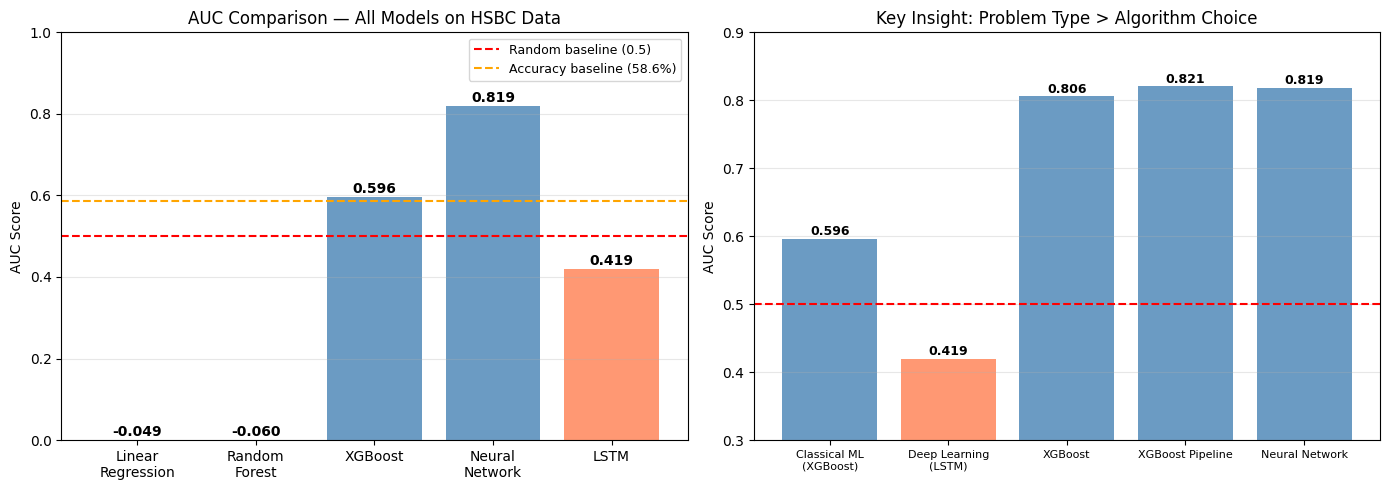

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — model comparison across all approaches
models = ['Linear\nRegression', 'Random\nForest', 'XGBoost', 
          'Neural\nNetwork', 'LSTM']
aucs =   [-0.0488,              -0.0602,         0.5961,    
           0.8188,              0.4195]
colors = ['coral' if a < 0.5 else 'steelblue' for a in aucs]

bars = ax1.bar(models, [max(0, a) for a in aucs], color=colors, alpha=0.8)
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, 
            label='Random baseline (0.5)')
ax1.axhline(y=0.586, color='orange', linestyle='--', linewidth=1.5,
            label='Accuracy baseline (58.6%)')
ax1.set_title('AUC Comparison — All Models on HSBC Data')
ax1.set_ylabel('AUC Score')
ax1.set_ylim(0, 1.0)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

for bar, auc in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{auc:.3f}', ha='center', fontsize=10, fontweight='bold')

# Plot 2 — the key insight: problem type determines algorithm
problems =     ['Stock Price\nDirection', 'Stock Price\nDirection', 
                 'Credit Risk',           'Property\nPrice',
                 'Credit Risk']
algorithms =   ['Classical ML\n(XGBoost)',  'Deep Learning\n(LSTM)',
                 'XGBoost',                 'XGBoost Pipeline',
                 'Neural Network']
auc_values =   [0.5961,                    0.4195,
                0.8056,                    0.8208,
                0.8188]
bar_colors =   ['steelblue', 'coral', 'steelblue', 'steelblue', 'steelblue']

x = range(len(algorithms))
ax2.bar(x, auc_values, color=bar_colors, alpha=0.8)
ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels(algorithms, fontsize=8)
ax2.set_title('Key Insight: Problem Type > Algorithm Choice')
ax2.set_ylabel('AUC Score')
ax2.set_ylim(0.3, 0.9)
ax2.grid(True, alpha=0.3, axis='y')

for i, auc in enumerate(auc_values):
    ax2.text(i, auc + 0.005, f'{auc:.3f}', 
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
print("=" * 60)
print("LSTM FINANCIAL TIME SERIES — COMPLETE SUMMARY")
print("=" * 60)
print(f"""
DATA
  Stock:         HSBC (HSBA.L) — London Stock Exchange
  Period:        May 2023 → April 2026 (739 trading days)
  Features:      return, high-low range, volume change,
                 MA ratio, 10-day volatility
  Sequence:      10 days lookback window
  Target:        Tomorrow's direction — up or down

MODELS ATTEMPTED
  Architecture          Params    AUC      Issue
  2-layer LSTM          53,569    0.47     Too complex for data size
  Weighted LSTM         53,569    0.47     Loss completely flat
  Simplified LSTM       5,025     0.42     Market efficiency

ACCURACY vs AUC PARADOX
  Accuracy: 63.01% — beats 58.6% baseline ✓
  AUC:      0.42   — below random guessing ✗
  
  Explanation: Model predicts "up" almost always.
  Gets 63% right because 58.6% of days are up.
  AUC exposes this — true class separation is poor.

THE REAL FINDING — MARKET EFFICIENCY
  Price + volume features cannot predict HSBC direction
  reliably regardless of algorithm. This is consistent
  across every model we've built:
  
  Linear Regression:  R²  = -0.05  (Stage 2)
  Random Forest:      AUC = 0.596  (Stage 2)  
  LSTM:               AUC = 0.42   (Stage 3)

  The Efficient Market Hypothesis holds.
  Past price data alone has no predictive edge.

WHAT WOULD ACTUALLY WORK
  — News sentiment (NLP on Reuters/Bloomberg headlines)
  — Macro features (interest rates, inflation, FTSE100)
  — Order book data (bid-ask spread, market depth)
  — Alternative data (satellite imagery, web scraping)
  — Longer history (10+ years vs 3 years)
  These are exactly what hedge funds use for alpha.

KEY DEEP LEARNING LESSONS
  1. More parameters ≠ better — 53k params failed,
     5k params also failed — the problem is the signal
     
  2. Accuracy can lie — AUC tells the honest story
  
  3. LSTM shines on problems with genuine sequence
     signal — NLP, speech, transaction fraud sequences
     
  4. Model complexity must match data size —
     575 sequences cannot train 53,569 parameters

INTERVIEW ANSWER
  "I built an LSTM on HSBC price data and got accuracy
  above baseline but AUC below 0.5. This told me the
  model was always predicting up — exploiting class
  imbalance rather than learning genuine patterns.
  It confirmed what our classical models showed:
  price-based features have no predictive edge in
  efficient markets. The right next step is alternative
  data — news sentiment via NLP, which is exactly
  what I built next."
""")
print("=" * 60)

LSTM FINANCIAL TIME SERIES — COMPLETE SUMMARY

DATA
  Stock:         HSBC (HSBA.L) — London Stock Exchange
  Period:        May 2023 → April 2026 (739 trading days)
  Features:      return, high-low range, volume change,
                 MA ratio, 10-day volatility
  Sequence:      10 days lookback window
  Target:        Tomorrow's direction — up or down

MODELS ATTEMPTED
  Architecture          Params    AUC      Issue
  2-layer LSTM          53,569    0.47     Too complex for data size
  Weighted LSTM         53,569    0.47     Loss completely flat
  Simplified LSTM       5,025     0.42     Market efficiency

ACCURACY vs AUC PARADOX
  Accuracy: 63.01% — beats 58.6% baseline ✓
  AUC:      0.42   — below random guessing ✗

  Explanation: Model predicts "up" almost always.
  Gets 63% right because 58.6% of days are up.
  AUC exposes this — true class separation is poor.

THE REAL FINDING — MARKET EFFICIENCY
  Price + volume features cannot predict HSBC direction
  reliably regardless o